# Liquidité intraday de TSLA avec LOBSTER

Ce notebook applique les notions de `references/Lecture_slides.pdf` aux
données LOBSTER de TSLA sur l'année 2019. Il est autonome: la préparation,
la fusion et l'analyse sont directement implémentées dans les cellules.

**Périmètre imposé:** seules les exécutions visibles de type
`Event Type == 4` sont étudiées. Les exécutions cachées de type `5` et
les autres événements LOBSTER sont exclus des statistiques d'impact.

Documentation de structure utilisée:
<https://php.lobsterdata.com/info/DataStructure.php>.

Dépendances Python nécessaires: `numpy`, `pandas`, `matplotlib`, `seaborn`,
`pyarrow` et `scipy`.

## 0. Méthode

Le parcours suit les slides:

1. cloner les fichiers bruts dans `../EI_liquidity_riad_working/`, hors du dépôt Git;
2. fusionner chaque fichier quotidien `message` avec son `orderbook`;
3. concaténer les jours et sélectionner les événements `4`;
4. construire bid, ask, spread, mid-price et rendements;
5. mesurer les faits stylisés et les impacts inconditionnel et conditionnel;
6. agréger le flux d'ordres sur plusieurs horizons;
7. ajuster l'analyse d'échelle finie, renormaliser et estimer le lambda de Kyle.

Selon LOBSTER, la ligne $k$ du fichier `message` explique la transition
du carnet entre les lignes $k-1$ et $k$ du fichier `orderbook`. Pour
mesurer $m_t$ immédiatement avant une exécution, la préparation conserve
donc l'état du carnet décalé d'une ligne.

In [1]:
"""LOBSTER preparation and liquidity analysis helpers for the TSLA notebook."""

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import re
import shutil
import subprocess
import sys
from typing import Iterable, Sequence

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from scipy.optimize import least_squares


PRICE_SCALE = 10_000.0
VISIBLE_EXECUTION_EVENT = 4
MESSAGE_COLUMNS = [
    "seconds",
    "event_type",
    "order_id",
    "size",
    "price_raw",
    "resting_order_direction",
]
FILE_PATTERN = re.compile(
    r"(?P<symbol>[A-Z]+)_(?P<date>\d{4}-\d{2}-\d{2})_"
    r"(?P<start>\d+)_(?P<end>\d+)_(?P<kind>message|orderbook)_"
    r"(?P<levels>\d+)\.csv"
)

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if not (ROOT / "TSLA").is_dir():
    raise RuntimeError("Le dossier brut TSLA/ doit etre present a la racine du depot.")

# Les fichiers clones et derives restent hors du depot Git.
WORK_DIR = ROOT.parent / "EI_liquidity_riad_working"

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

### Fonctions autonomes de préparation et d'analyse

Les cellules suivantes contiennent toute l'implémentation utilisée par le
notebook. Aucun module local ni script externe n'est nécessaire.

In [2]:
@dataclass(frozen=True)
class DailyFiles:
    symbol: str
    date: str
    start: str
    end: str
    levels: int
    message_path: Path
    orderbook_path: Path


@dataclass(frozen=True)
class PreparedPaths:
    visible_executions: Path
    market_orders: Path
    daily_summary: Path


def clone_raw_data(source_dir: Path | str, destination_dir: Path | str) -> Path:
    """Create an isolated raw-data working copy, using APFS clones when possible."""

    source = Path(source_dir)
    destination = Path(destination_dir)
    if destination.exists():
        return destination
    if not source.is_dir():
        raise FileNotFoundError(f"Raw LOBSTER directory not found: {source}")

    destination.parent.mkdir(parents=True, exist_ok=True)
    if sys.platform == "darwin":
        try:
            subprocess.run(
                ["cp", "-cR", str(source), str(destination)],
                check=True,
                capture_output=True,
                text=True,
            )
            return destination
        except subprocess.CalledProcessError:
            pass

    shutil.copytree(source, destination)
    return destination


def discover_daily_files(raw_dir: Path | str, symbol: str = "TSLA") -> list[DailyFiles]:
    """Return complete daily message/orderbook pairs in chronological order."""

    raw_path = Path(raw_dir)
    grouped: dict[tuple[str, str, str, int], dict[str, Path]] = {}
    for path in sorted(raw_path.glob(f"{symbol}_*.csv")):
        match = FILE_PATTERN.fullmatch(path.name)
        if not match or match.group("symbol") != symbol:
            continue
        key = (
            match.group("date"),
            match.group("start"),
            match.group("end"),
            int(match.group("levels")),
        )
        grouped.setdefault(key, {})[match.group("kind")] = path

    pairs: list[DailyFiles] = []
    for (date, start, end, levels), files in sorted(grouped.items()):
        missing = {"message", "orderbook"} - files.keys()
        if missing:
            raise ValueError(f"Incomplete LOBSTER pair for {date}: missing {sorted(missing)}")
        pairs.append(
            DailyFiles(
                symbol=symbol,
                date=date,
                start=start,
                end=end,
                levels=levels,
                message_path=files["message"],
                orderbook_path=files["orderbook"],
            )
        )
    if not pairs:
        raise FileNotFoundError(f"No LOBSTER files found for {symbol} in {raw_path}")
    return pairs


def orderbook_columns(levels: int) -> list[str]:
    columns: list[str] = []
    for level in range(1, levels + 1):
        columns.extend(
            [
                f"ask_price_{level}",
                f"ask_size_{level}",
                f"bid_price_{level}",
                f"bid_size_{level}",
            ]
        )
    return columns


def read_visible_executions(day: DailyFiles) -> tuple[pd.DataFrame, int]:
    """Join aligned LOBSTER rows and retain visible limit-order executions only.

    LOBSTER row k describes the event that changes the book from row k - 1 to
    row k. The returned table therefore contains both pre-event and post-event
    book states. The first row is discarded when it is a type-4 event because
    its pre-event state is not available in the daily file.
    """

    messages = pd.read_csv(
        day.message_path,
        header=None,
        usecols=range(len(MESSAGE_COLUMNS)),
        names=MESSAGE_COLUMNS,
    )

    book_columns = orderbook_columns(day.levels)
    orderbook = pd.read_csv(day.orderbook_path, header=None, names=book_columns)
    if len(messages) != len(orderbook):
        raise ValueError(
            f"LOBSTER alignment failure for {day.date}: "
            f"{len(messages)} message rows != {len(orderbook)} book rows"
        )

    event_rows = np.flatnonzero(
        messages["event_type"].to_numpy() == VISIBLE_EXECUTION_EVENT
    )
    event_rows = event_rows[event_rows > 0]
    selected = messages.iloc[event_rows].reset_index(drop=True)

    before = orderbook.iloc[event_rows - 1].reset_index(drop=True)
    before.columns = [f"{column}_before" for column in before.columns]
    after = orderbook.iloc[event_rows].reset_index(drop=True)
    after.columns = [f"{column}_after" for column in after.columns]

    executions = pd.concat([selected, before, after], axis=1)
    executions.insert(0, "date", day.date)
    executions.insert(1, "timestamp", _timestamps(day.date, executions["seconds"]))
    executions.insert(3, "event_row", event_rows)
    executions["execution_price"] = executions.pop("price_raw") / PRICE_SCALE
    executions["trade_sign"] = -executions["resting_order_direction"]

    price_columns = [
        column
        for column in executions.columns
        if "_price_" in column and column.endswith(("_before", "_after"))
    ]
    executions[price_columns] = executions[price_columns] / PRICE_SCALE
    executions["mid_price_before"] = (
        executions["ask_price_1_before"] + executions["bid_price_1_before"]
    ) / 2
    executions["mid_price_after"] = (
        executions["ask_price_1_after"] + executions["bid_price_1_after"]
    ) / 2
    executions["spread_before"] = (
        executions["ask_price_1_before"] - executions["bid_price_1_before"]
    )
    executions["same_side_queue_before"] = np.where(
        executions["trade_sign"].eq(1),
        executions["ask_size_1_before"],
        executions["bid_size_1_before"],
    )
    return executions, len(messages)


def aggregate_market_orders(executions: pd.DataFrame) -> pd.DataFrame:
    """Batch visible executions sharing a timestamp and initiator direction."""

    if executions.empty:
        return executions.copy()

    ordered = executions.sort_values(["date", "event_row"]).copy()
    previous = ordered.shift()
    starts_new_order = (
        ordered["date"].ne(previous["date"])
        | ordered["seconds"].ne(previous["seconds"])
        | ordered["trade_sign"].ne(previous["trade_sign"])
        | ordered["event_row"].sub(previous["event_row"]).ne(1)
    )
    ordered["_market_order_group"] = starts_new_order.cumsum()
    keys = ["date", "_market_order_group"]
    grouped = ordered.groupby(keys, sort=True, observed=True)
    aggregations: dict[str, tuple[str, str]] = {
        "seconds": ("seconds", "first"),
        "trade_sign": ("trade_sign", "first"),
        "timestamp": ("timestamp", "first"),
        "event_type": ("event_type", "first"),
        "first_event_row": ("event_row", "first"),
        "last_event_row": ("event_row", "last"),
        "visible_execution_count": ("event_type", "size"),
        "size": ("size", "sum"),
        "resting_order_direction": ("resting_order_direction", "first"),
        "mid_price_before": ("mid_price_before", "first"),
        "mid_price_after": ("mid_price_after", "last"),
        "spread_before": ("spread_before", "first"),
        "same_side_queue_before": ("same_side_queue_before", "first"),
    }
    for column in executions.columns:
        if column.endswith("_before") and column not in {
            "mid_price_before",
            "spread_before",
            "same_side_queue_before",
        }:
            aggregations[column] = (column, "first")
        elif column.endswith("_after") and column != "mid_price_after":
            aggregations[column] = (column, "last")

    market_orders = grouped.agg(**aggregations).reset_index()
    weighted_notional = (ordered["execution_price"] * ordered["size"]).groupby(
        [ordered[column] for column in keys]
    ).sum()
    total_size = grouped["size"].sum()
    market_orders["execution_price_vwap"] = (
        weighted_notional / total_size
    ).to_numpy()
    market_orders["signed_volume"] = market_orders["trade_sign"] * market_orders["size"]
    return (
        market_orders.drop(columns="_market_order_group")
        .sort_values(["date", "first_event_row"])
        .reset_index(drop=True)
    )


def prepare_type4_dataset(
    raw_dir: Path | str,
    processed_dir: Path | str,
    symbol: str = "TSLA",
    year: int = 2019,
    force: bool = False,
) -> PreparedPaths:
    """Horizontally join daily files and vertically append annual type-4 tables."""

    output_dir = Path(processed_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    paths = PreparedPaths(
        visible_executions=output_dir / f"{symbol}_{year}_type4_visible_executions.parquet",
        market_orders=output_dir / f"{symbol}_{year}_type4_market_orders.parquet",
        daily_summary=output_dir / f"{symbol}_{year}_type4_daily_summary.csv",
    )
    if not force and all(path.exists() for path in paths.__dict__.values()):
        return paths

    pairs = [
        pair for pair in discover_daily_files(raw_dir, symbol=symbol)
        if pair.date.startswith(f"{year}-")
    ]
    if not pairs:
        raise FileNotFoundError(f"No {symbol} LOBSTER files found for {year}")

    temporary = {
        name: path.with_suffix(path.suffix + ".tmp")
        for name, path in paths.__dict__.items()
    }
    for path in temporary.values():
        path.unlink(missing_ok=True)

    visible_writer: pq.ParquetWriter | None = None
    market_writer: pq.ParquetWriter | None = None
    summaries: list[dict[str, object]] = []
    try:
        for pair in pairs:
            executions, message_rows = read_visible_executions(pair)
            market_orders = aggregate_market_orders(executions)
            visible_writer = _append_parquet(
                visible_writer, temporary["visible_executions"], executions
            )
            market_writer = _append_parquet(
                market_writer, temporary["market_orders"], market_orders
            )
            summaries.append(
                {
                    "date": pair.date,
                    "message_rows": message_rows,
                    "visible_executions": len(executions),
                    "market_orders": len(market_orders),
                    "visible_volume": int(executions["size"].sum()),
                }
            )
    finally:
        if visible_writer is not None:
            visible_writer.close()
        if market_writer is not None:
            market_writer.close()

    pd.DataFrame(summaries).to_csv(temporary["daily_summary"], index=False)
    for name, path in paths.__dict__.items():
        temporary[name].replace(path)
    return paths

In [3]:
def add_lag1_features(market_orders: pd.DataFrame) -> pd.DataFrame:
    """Add one-trade-ahead impact and daily normalisation columns."""

    trades = market_orders.sort_values(_trade_sort_columns(market_orders)).copy()
    by_day = trades.groupby("date", sort=True, observed=True)
    trades["next_mid_price"] = by_day["mid_price_before"].shift(-1)
    trades["lag1_mid_change"] = trades["next_mid_price"] - trades["mid_price_before"]
    trades["lag1_signed_impact"] = trades["trade_sign"] * trades["lag1_mid_change"]
    trades["daily_volume"] = by_day["size"].transform("sum")
    trades["daily_r1"] = trades.groupby("date", observed=True)[
        "lag1_signed_impact"
    ].transform("mean")
    trades["average_same_side_queue"] = trades.groupby("date", observed=True)[
        "same_side_queue_before"
    ].transform("mean")
    trades["normalised_trade_volume"] = (
        trades["size"] / trades["average_same_side_queue"]
    )
    trades["normalised_lag1_impact"] = trades["lag1_signed_impact"] / trades["daily_r1"]
    return trades


def compute_response(market_orders: pd.DataFrame, max_lag: int = 50) -> pd.DataFrame:
    """Estimate unconditional response R(l) without crossing daily boundaries."""

    totals = np.zeros(max_lag, dtype=float)
    counts = np.zeros(max_lag, dtype=np.int64)
    for _, day in market_orders.groupby("date", sort=True, observed=True):
        ordered = day.sort_values(_trade_sort_columns(day, include_date=False))
        mid = ordered["mid_price_before"].to_numpy(dtype=float)
        signs = ordered["trade_sign"].to_numpy(dtype=float)
        for lag in range(1, min(max_lag, len(day) - 1) + 1):
            values = signs[:-lag] * (mid[lag:] - mid[:-lag])
            valid = np.isfinite(values)
            totals[lag - 1] += values[valid].sum()
            counts[lag - 1] += valid.sum()
    response = np.divide(totals, counts, out=np.full(max_lag, np.nan), where=counts > 0)
    return pd.DataFrame({"lag": np.arange(1, max_lag + 1), "response": response, "count": counts})


def compute_event_time_returns(
    market_orders: pd.DataFrame, horizons: Sequence[int] = (1, 10, 100)
) -> pd.DataFrame:
    """Compute log returns at several market-order event-time horizons."""

    frames: list[pd.DataFrame] = []
    for horizon in horizons:
        for date, day in market_orders.groupby("date", sort=True, observed=True):
            ordered = day.sort_values(_trade_sort_columns(day, include_date=False))
            mid = ordered["mid_price_before"]
            values = np.log(mid.shift(-horizon)) - np.log(mid)
            frames.append(
                pd.DataFrame(
                    {
                        "date": date,
                        "horizon": horizon,
                        "log_return": values.dropna().to_numpy(),
                    }
                )
            )
    return pd.concat(frames, ignore_index=True)


def autocorrelation_by_day(
    data: pd.DataFrame, value_column: str, max_lag: int = 50
) -> pd.DataFrame:
    """Estimate autocorrelation while keeping each trading day independent."""

    clean = data[["date", value_column]].dropna()
    mean = clean[value_column].mean()
    variance = clean[value_column].var(ddof=0)
    rows: list[dict[str, float | int]] = []
    for lag in range(1, max_lag + 1):
        total = 0.0
        count = 0
        for _, day in clean.groupby("date", sort=True, observed=True):
            values = day[value_column].to_numpy(dtype=float)
            if len(values) <= lag:
                continue
            total += ((values[:-lag] - mean) * (values[lag:] - mean)).sum()
            count += len(values) - lag
        rows.append(
            {
                "lag": lag,
                "autocorrelation": total / count / variance if count and variance else np.nan,
                "count": count,
            }
        )
    return pd.DataFrame(rows)


def bin_conditional_impact(
    trades: pd.DataFrame, quantiles: int = 30
) -> pd.DataFrame:
    """Average lag-1 impact conditional on normalised trade volume."""

    clean = trades.replace([np.inf, -np.inf], np.nan).dropna(
        subset=["normalised_trade_volume", "normalised_lag1_impact"]
    )
    labels = pd.qcut(clean["normalised_trade_volume"], q=quantiles, duplicates="drop")
    return (
        clean.assign(volume_bin=labels)
        .groupby("volume_bin", observed=True)
        .agg(
            normalised_trade_volume=("normalised_trade_volume", "mean"),
            normalised_lag1_impact=("normalised_lag1_impact", "mean"),
            observations=("normalised_lag1_impact", "size"),
        )
        .reset_index(drop=True)
    )


def compute_aggregate_windows(
    trades: pd.DataFrame,
    horizons: Sequence[int] = (5, 10, 20, 50, 100),
    stride: str | int = "horizon",
) -> pd.DataFrame:
    """Compute coarse-grained signed imbalances and impact within each day.

    The notebook uses non-overlapping windows (stride == "horizon"), matching a
    coarse-graining operation while keeping the annual dataset tractable. Pass
    stride=1 to enumerate every overlapping window.
    """

    frames: list[pd.DataFrame] = []
    for date, day in trades.groupby("date", sort=True, observed=True):
        ordered = day.sort_values(_trade_sort_columns(day, include_date=False))
        mid = ordered["mid_price_before"].to_numpy(dtype=float)
        size = ordered["size"].to_numpy(dtype=float)
        sign = ordered["trade_sign"].to_numpy(dtype=float)
        signed_volume = size * sign
        daily_volume = size.sum()
        daily_r1 = ordered["lag1_signed_impact"].mean()
        if not np.isfinite(daily_r1) or daily_r1 <= 0 or daily_volume <= 0:
            continue
        signed_volume_cumsum = np.r_[0.0, np.cumsum(signed_volume)]
        sign_cumsum = np.r_[0.0, np.cumsum(sign)]

        for horizon in horizons:
            step = horizon if stride == "horizon" else int(stride)
            starts = np.arange(0, len(ordered) - horizon, step)
            if not len(starts):
                continue
            stops = starts + horizon
            volume_imbalance = signed_volume_cumsum[stops] - signed_volume_cumsum[starts]
            order_flow_imbalance = sign_cumsum[stops] - sign_cumsum[starts]
            impact = mid[stops] - mid[starts]
            frames.append(
                pd.DataFrame(
                    {
                        "date": date,
                        "horizon": horizon,
                        "volume_imbalance": volume_imbalance,
                        "order_flow_imbalance": order_flow_imbalance,
                        "impact": impact,
                        "daily_volume": daily_volume,
                        "daily_r1": daily_r1,
                        "normalised_volume_imbalance": volume_imbalance / daily_volume,
                        "normalised_impact": impact / daily_r1,
                    }
                )
            )
    return pd.concat(frames, ignore_index=True)


def quantile_impact_curve(
    windows: pd.DataFrame, quantiles: int = 31
) -> pd.DataFrame:
    """Denoise aggregate impact with separate imbalance quantiles for each T."""

    frames: list[pd.DataFrame] = []
    for horizon, part in windows.groupby("horizon", sort=True, observed=True):
        labels = pd.qcut(
            part["normalised_volume_imbalance"], q=quantiles, duplicates="drop"
        )
        curve = (
            part.assign(imbalance_bin=labels)
            .groupby("imbalance_bin", observed=True)
            .agg(
                normalised_volume_imbalance=("normalised_volume_imbalance", "mean"),
                normalised_impact=("normalised_impact", "mean"),
                impact=("impact", "mean"),
                volume_imbalance=("volume_imbalance", "mean"),
                observations=("normalised_impact", "size"),
            )
            .reset_index(drop=True)
        )
        curve.insert(0, "horizon", horizon)
        frames.append(curve)
    return pd.concat(frames, ignore_index=True)


def master_curve(x: np.ndarray, alpha: float, beta: float) -> np.ndarray:
    """Sigmoidal scaling function from the lecture slides."""

    return x / np.power(1 + np.power(np.abs(x), alpha), beta / alpha)


def fit_finite_size_scaling(curve: pd.DataFrame) -> dict[str, float]:
    """Fit exponents and nuisance scales for a finite-size scaling collapse."""

    x = curve["normalised_volume_imbalance"].to_numpy(dtype=float)
    y = curve["normalised_impact"].to_numpy(dtype=float)
    horizon = curve["horizon"].to_numpy(dtype=float)
    weights = np.sqrt(curve["observations"].to_numpy(dtype=float))
    weights /= weights.max()

    def prediction(parameters: np.ndarray) -> np.ndarray:
        amplitude, x_scale, xi, psi, alpha, beta = parameters
        scaled_x = x * np.power(horizon, -xi) / x_scale
        return amplitude * np.power(horizon, psi) * master_curve(scaled_x, alpha, beta)

    def residuals(parameters: np.ndarray) -> np.ndarray:
        return weights * (prediction(parameters) - y)

    result = least_squares(
        residuals,
        x0=np.array([1.0, 0.001, 0.5, 0.3, 1.5, 0.5]),
        bounds=(
            np.array([1e-6, 1e-7, -1.0, -1.0, 0.1, 0.01]),
            np.array([1e4, 1.0, 2.0, 2.0, 8.0, 4.0]),
        ),
        loss="soft_l1",
        max_nfev=20_000,
    )
    amplitude, x_scale, xi, psi, alpha, beta = result.x
    return {
        "amplitude": float(amplitude),
        "x_scale": float(x_scale),
        "xi": float(xi),
        "psi": float(psi),
        "alpha": float(alpha),
        "beta": float(beta),
        "lambda_exponent": float(xi - psi),
        "cost": float(result.cost),
        "success": bool(result.success),
    }


def renormalise_curve(curve: pd.DataFrame, parameters: dict[str, float]) -> pd.DataFrame:
    """Apply the fitted finite-size scaling transformation."""

    result = curve.copy()
    result["master_x"] = (
        result["normalised_volume_imbalance"]
        * np.power(result["horizon"], -parameters["xi"])
        / parameters["x_scale"]
    )
    result["master_y"] = (
        result["normalised_impact"]
        / parameters["amplitude"]
        / np.power(result["horizon"], parameters["psi"])
    )
    return result


def estimate_kyle_lambdas(
    windows: pd.DataFrame, central_quantile: float = 0.35
) -> pd.DataFrame:
    """Estimate Kyle's lambda in the central, approximately linear region."""

    rows: list[dict[str, float | int]] = []
    for horizon, part in windows.groupby("horizon", sort=True, observed=True):
        threshold = part["volume_imbalance"].abs().quantile(central_quantile)
        central = part[part["volume_imbalance"].abs() <= threshold]
        x = central["volume_imbalance"].to_numpy(dtype=float)
        y = central["impact"].to_numpy(dtype=float) * 100
        design = np.column_stack([np.ones(len(x)), x])
        intercept, slope = np.linalg.lstsq(design, y, rcond=None)[0]
        rows.append(
            {
                "horizon": int(horizon),
                "threshold_shares": float(threshold),
                "intercept_cents": float(intercept),
                "kyle_lambda_cents_per_share": float(slope),
                "observations": len(central),
            }
        )
    return pd.DataFrame(rows)


def fit_kyle_decay(kyle_lambdas: pd.DataFrame) -> dict[str, float]:
    """Fit lambda(T) proportional to T**(-exponent)."""

    clean = kyle_lambdas[kyle_lambdas["kyle_lambda_cents_per_share"] > 0]
    x = np.log(clean["horizon"].to_numpy(dtype=float))
    y = np.log(clean["kyle_lambda_cents_per_share"].to_numpy(dtype=float))
    intercept, slope = np.linalg.lstsq(
        np.column_stack([np.ones(len(x)), x]), y, rcond=None
    )[0]
    return {"prefactor": float(np.exp(intercept)), "lambda_exponent": float(-slope)}


def _append_parquet(
    writer: pq.ParquetWriter | None, output_path: Path, frame: pd.DataFrame
) -> pq.ParquetWriter:
    table = pa.Table.from_pandas(frame, preserve_index=False)
    if writer is None:
        writer = pq.ParquetWriter(output_path, table.schema, compression="zstd")
    writer.write_table(table)
    return writer


def _timestamps(date: str, seconds: Iterable[float]) -> pd.Series:
    return pd.Timestamp(date) + pd.to_timedelta(pd.Series(seconds), unit="s")


def _trade_sort_columns(data: pd.DataFrame, include_date: bool = True) -> list[str]:
    columns = ["date"] if include_date else []
    if "first_event_row" in data.columns:
        return columns + ["first_event_row"]
    return columns + ["seconds", "trade_sign"]

## 1. Préparation LOBSTER

LOBSTER fournit deux matrices par jour actif:

- `message`: temps, type d'événement, identifiant, taille, prix et direction;
- `orderbook`: prix et taille ask/bid pour chacun des niveaux demandés.

La direction LOBSTER est celle de l'ordre limite consommé. Pour une
exécution visible, le signe de l'ordre au marché initiateur est donc
l'opposé: une limite de vente exécutée (`Direction == -1`) correspond à
un achat initiateur ($\varepsilon=+1$).

In [4]:
SYMBOL = "TSLA"
YEAR = 2019
SOURCE_RAW_DIR = ROOT / "TSLA"
CLONED_RAW_DIR = WORK_DIR / "raw" / "TSLA"
PROCESSED_DIR = WORK_DIR / "processed"

raw_working_copy = clone_raw_data(SOURCE_RAW_DIR, CLONED_RAW_DIR)
prepared = prepare_type4_dataset(
    raw_dir=raw_working_copy,
    processed_dir=PROCESSED_DIR,
    symbol=SYMBOL,
    year=YEAR,
)
prepared

PreparedPaths(visible_executions=PosixPath('/Users/fuser/Documents/Finance/EI/EI_liquidity_riad_working/processed/TSLA_2019_type4_visible_executions.parquet'), market_orders=PosixPath('/Users/fuser/Documents/Finance/EI/EI_liquidity_riad_working/processed/TSLA_2019_type4_market_orders.parquet'), daily_summary=PosixPath('/Users/fuser/Documents/Finance/EI/EI_liquidity_riad_working/processed/TSLA_2019_type4_daily_summary.csv'))

In [5]:
summary = pd.read_csv(prepared.daily_summary)
trade_columns = [
    "date", "timestamp", "seconds", "first_event_row", "trade_sign", "size",
    "execution_price_vwap", "mid_price_before", "mid_price_after",
    "spread_before", "same_side_queue_before", "ask_price_1_before",
    "ask_size_1_before", "bid_price_1_before", "bid_size_1_before",
]
trades = pd.read_parquet(prepared.market_orders, columns=trade_columns)

parquet = pq.ParquetFile(prepared.visible_executions)
execution_preview = parquet.read_row_group(
    0,
    columns=[
        "date", "timestamp", "event_type", "size", "execution_price",
        "resting_order_direction", "trade_sign", "mid_price_before",
        "mid_price_after",
    ],
).to_pandas().head()

quality = pd.Series(
    {
        "jours": len(summary),
        "lignes message": summary["message_rows"].sum(),
        "executions visibles type 4": summary["visible_executions"].sum(),
        "ordres au marche agreges": summary["market_orders"].sum(),
        "volume visible": summary["visible_volume"].sum(),
        "premier jour": summary["date"].min(),
        "dernier jour": summary["date"].max(),
    },
    name="TSLA 2019",
)
display(quality.to_frame())
display(execution_preview)

,TSLA 2019
jours,252
lignes message,38721930
executions visibles type 4,6504032
ordres au marche agreges,4615419
volume visible,417147685
premier jour,2019-01-02
dernier jour,2019-12-31


,date,timestamp,event_type,size,execution_price,resting_order_direction,trade_sign,mid_price_before,mid_price_after
0,2019-01-02,2019-01-02 09:30:00.548210475,4,3,306.51,-1,1,306.285,306.515
1,2019-01-02,2019-01-02 09:30:00.594026954,4,250,306.97,-1,1,306.515,306.530
2,2019-01-02,2019-01-02 09:30:00.801002624,4,12,306.67,-1,1,306.365,306.365
3,2019-01-02,2019-01-02 09:30:00.803690081,4,488,306.67,-1,1,306.365,306.530
4,2019-01-02,2019-01-02 09:30:00.832255334,4,4,306.67,-1,1,306.365,306.530


Les exécutions qui partagent exactement le même horodatage et le même
signe initiateur sont regroupées: un ordre au marché peut consommer
plusieurs ordres limites successifs. Cette agrégation reconstitue son
volume total avant d'étudier l'impact.

## 2. Carnet limite, spread et mid-price

Pour le meilleur niveau:

$$
b(t)=\max B(t), \qquad a(t)=\min A(t),
$$

$$
s(t)=a(t)-b(t), \qquad m(t)=\frac{a(t)+b(t)}{2}.
$$

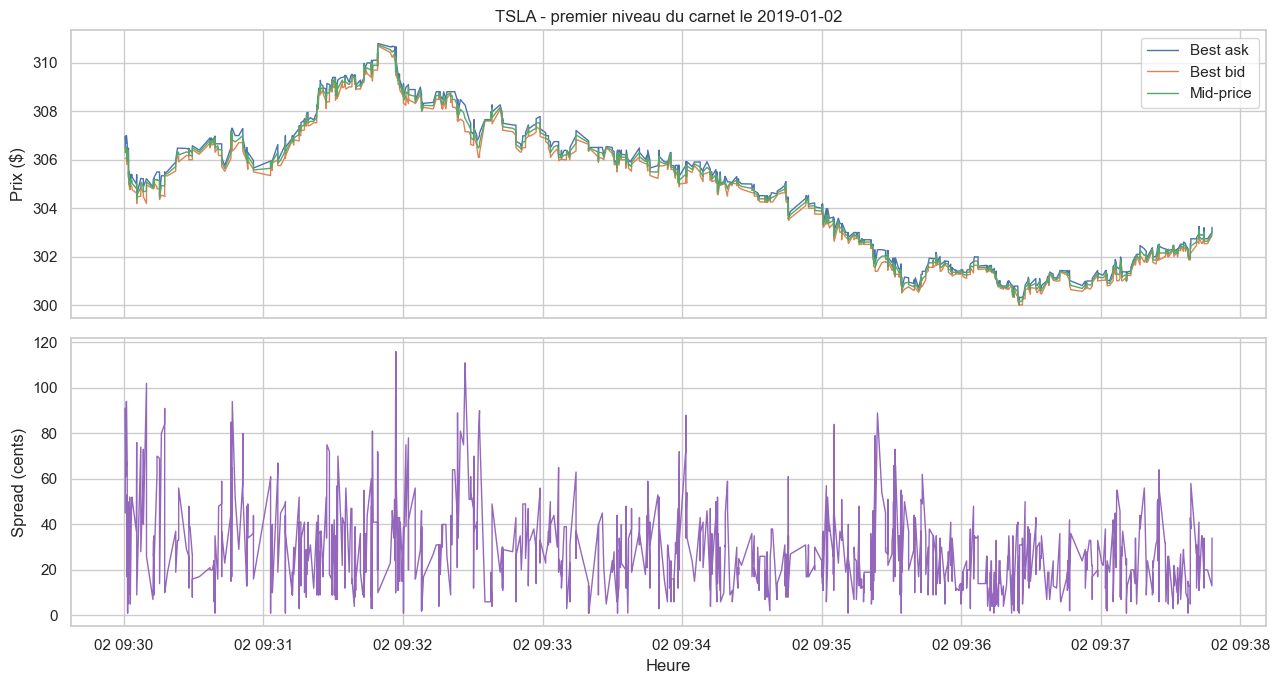

In [6]:
sample_date = summary.loc[0, "date"]
sample = trades[trades["date"].eq(sample_date)].head(2_000)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(sample["timestamp"], sample["ask_price_1_before"], label="Best ask", lw=1)
axes[0].plot(sample["timestamp"], sample["bid_price_1_before"], label="Best bid", lw=1)
axes[0].plot(sample["timestamp"], sample["mid_price_before"], label="Mid-price", lw=1)
axes[0].set_ylabel("Prix ($)")
axes[0].set_title(f"{SYMBOL} - premier niveau du carnet le {sample_date}")
axes[0].legend()
axes[1].plot(sample["timestamp"], sample["spread_before"] * 100, color="tab:purple", lw=1)
axes[1].set_ylabel("Spread (cents)")
axes[1].set_xlabel("Heure")
plt.tight_layout()
plt.show()

## 3. Rendements et faits stylisés

Les slides définissent le rendement en temps-événement par

$$
\mathcal{R}(\ell)=m_{t+\ell}-m_t.
$$

Nous illustrons deux faits stylisés sur les vingt premiers jours:

- les distributions changent d'échelle et se rapprochent progressivement
  d'une forme gaussienne lorsqu'on agrège;
- les signes d'ordres et les amplitudes des variations présentent de
  l'autocorrélation.

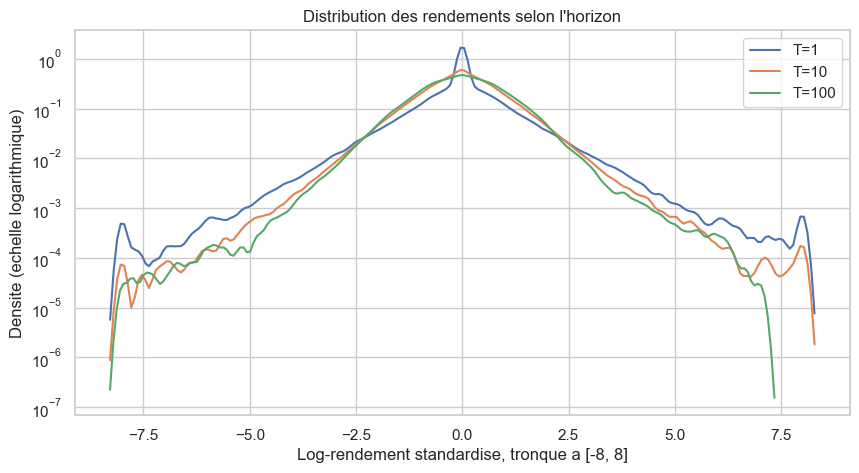

In [7]:
exploratory_dates = summary["date"].head(20)
exploratory = trades[trades["date"].isin(exploratory_dates)].copy()
exploratory_features = add_lag1_features(exploratory)
event_returns = compute_event_time_returns(exploratory, horizons=(1, 10, 100))
event_returns["standardised_return"] = event_returns.groupby("horizon")[
    "log_return"
].transform(lambda values: (values - values.mean()) / values.std())

fig, ax = plt.subplots(figsize=(10, 5))
for horizon, part in event_returns.groupby("horizon"):
    sns.kdeplot(
        part["standardised_return"].clip(-8, 8),
        ax=ax,
        label=f"T={horizon}",
        bw_adjust=1.2,
    )
ax.set_yscale("log")
ax.set_xlabel("Log-rendement standardise, tronque a [-8, 8]")
ax.set_ylabel("Densite (echelle logarithmique)")
ax.set_title("Distribution des rendements selon l'horizon")
ax.legend()
plt.show()

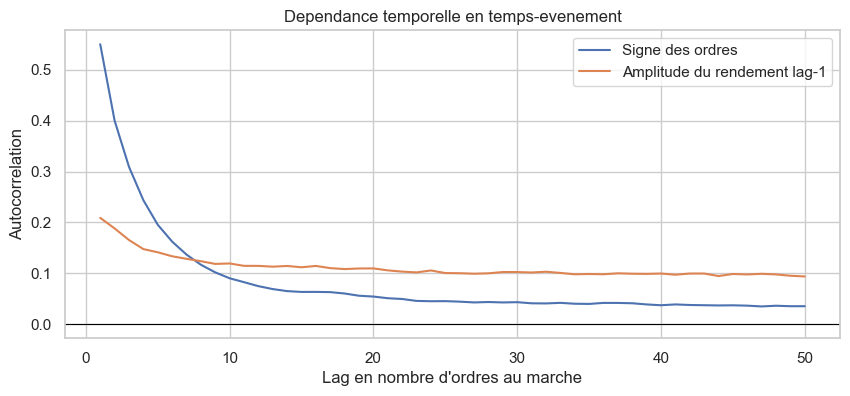

In [8]:
sign_acf = autocorrelation_by_day(exploratory, "trade_sign", max_lag=50)
exploratory_features["absolute_lag1_change"] = exploratory_features[
    "lag1_mid_change"
].abs()
absolute_return_acf = autocorrelation_by_day(
    exploratory_features, "absolute_lag1_change", max_lag=50
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sign_acf["lag"], sign_acf["autocorrelation"], label="Signe des ordres")
ax.plot(
    absolute_return_acf["lag"],
    absolute_return_acf["autocorrelation"],
    label="Amplitude du rendement lag-1",
)
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Lag en nombre d'ordres au marche")
ax.set_ylabel("Autocorrelation")
ax.set_title("Dependance temporelle en temps-evenement")
ax.legend()
plt.show()

## 4. Impact inconditionnel et conditionnel

L'impact inconditionnel est la fonction de réponse:

$$
R_m(\ell)=\left\langle
\varepsilon_t\left(m_{t+\ell}-m_t\right)
\right\rangle.
$$

Sa valeur à un pas, $R(1)$, sert ensuite d'échelle quotidienne. Pour
l'impact conditionnel, on rapporte le volume de l'ordre à la profondeur
moyenne disponible du même côté du carnet.

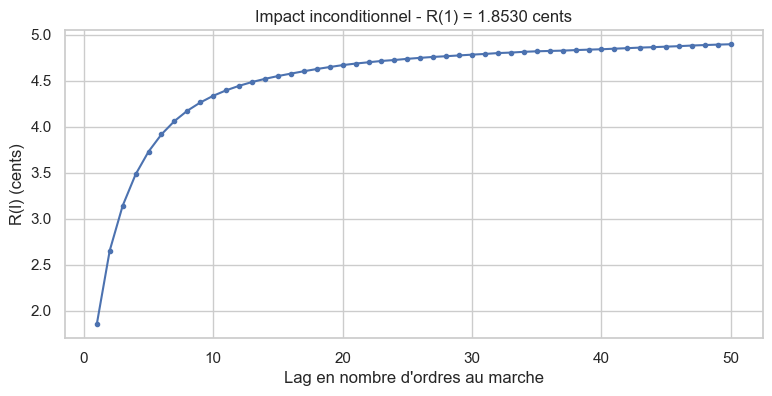

In [9]:
response = compute_response(trades, max_lag=50)
r1 = response.loc[response["lag"].eq(1), "response"].iloc[0]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(response["lag"], response["response"] * 100, marker="o", ms=3)
ax.set_xlabel("Lag en nombre d'ordres au marche")
ax.set_ylabel("R(l) (cents)")
ax.set_title(f"Impact inconditionnel - R(1) = {r1 * 100:.4f} cents")
plt.show()

In [10]:
features = add_lag1_features(trades)
daily_r1 = (
    features.groupby("date", observed=True)
    .agg(
        daily_r1=("daily_r1", "first"),
        daily_volume=("daily_volume", "first"),
        trades=("size", "size"),
    )
    .reset_index()
)
positive_daily_r1 = daily_r1.loc[daily_r1["daily_r1"] > 0, "daily_r1"]
r1_floor = positive_daily_r1.quantile(0.05)
stable_features = features[features["daily_r1"] >= r1_floor].copy()

display(daily_r1.describe())
print(
    "Filtre de stabilite pour les normalisations quotidiennes: "
    f"R(1) >= {r1_floor * 100:.6f} cents."
)

,daily_r1,daily_volume,trades
count,252.000000,2.520000e+02,252.000000
mean,0.019196,1.655348e+06,18315.154762
std,0.006231,8.124392e+05,7924.279862
min,0.010212,3.084400e+04,408.000000
25%,0.015307,1.120000e+06,13034.000000
50%,0.018310,1.462074e+06,16145.000000
75%,0.021086,1.927566e+06,21087.000000
max,0.079779,4.699501e+06,48639.000000


Filtre de stabilite pour les normalisations quotidiennes: R(1) >= 1.298808 cents.


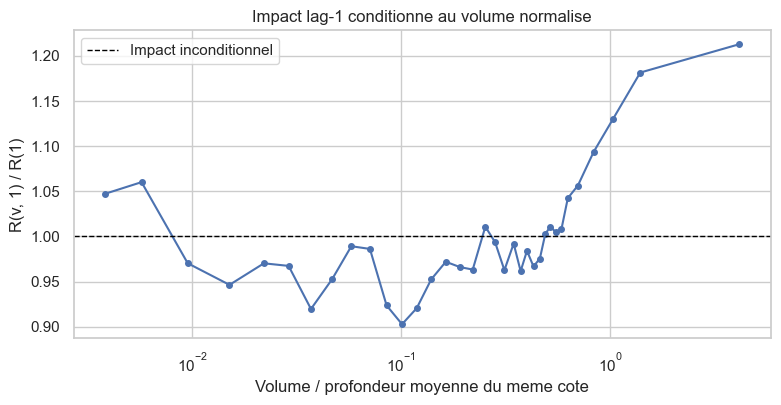

In [11]:
conditional_curve = bin_conditional_impact(stable_features, quantiles=35)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(
    conditional_curve["normalised_trade_volume"],
    conditional_curve["normalised_lag1_impact"],
    marker="o",
    ms=4,
)
ax.axhline(1, color="black", ls="--", lw=1, label="Impact inconditionnel")
ax.set_xscale("log")
ax.set_xlabel("Volume / profondeur moyenne du meme cote")
ax.set_ylabel("R(v, 1) / R(1)")
ax.set_title("Impact lag-1 conditionne au volume normalise")
ax.legend()
plt.show()

## 5. Impact agrégé et déséquilibre de flux

Pour une fenêtre contenant $T$ ordres au marché successifs du même jour:

$$
\Delta \varepsilon=\sum_{n=t}^{t+T-1}\varepsilon_n,
\qquad
\Delta V=\sum_{n=t}^{t+T-1}\varepsilon_n v_n,
$$

$$
R(\Delta V,T)=\left\langle m_{t+T}-m_t\mid\Delta V\right\rangle.
$$

Nous utilisons des fenêtres non chevauchantes pour matérialiser le
coarse-graining et garder l'analyse annuelle calculable sur une machine
standard. La fonction accepte `stride=1` pour énumérer toutes les
fenêtres chevauchantes.

In [12]:
HORIZONS = (5, 10, 20, 50, 100)
windows = compute_aggregate_windows(
    stable_features,
    horizons=HORIZONS,
    stride="horizon",
)
impact_curve = quantile_impact_curve(windows, quantiles=31)

display(windows.groupby("horizon").size().rename("fenetres").to_frame())

,fenetres
horizon,
5,854119
10,427001
20,213448
50,85311
100,42596


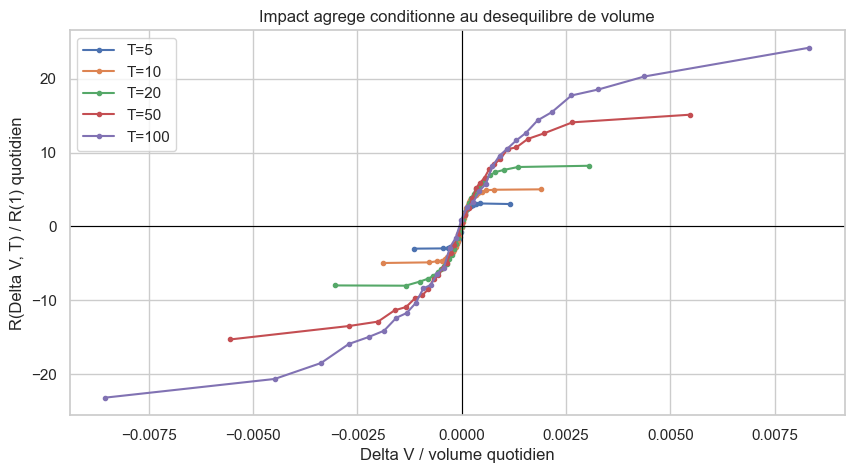

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
for horizon, part in impact_curve.groupby("horizon"):
    ax.plot(
        part["normalised_volume_imbalance"],
        part["normalised_impact"],
        marker="o",
        ms=3,
        label=f"T={horizon}",
    )
ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Delta V / volume quotidien")
ax.set_ylabel("R(Delta V, T) / R(1) quotidien")
ax.set_title("Impact agrege conditionne au desequilibre de volume")
ax.legend()
plt.show()

## 6. Analyse d'échelle finie et renormalisation

Les slides posent:

$$
R(\Delta V,T)\approx R(1)T^\psi
\mathcal{F}\left(\frac{\Delta V}{V_D T^\xi}\right),
$$

avec la fonction sigmoïde:

$$
\mathcal{F}(x)=\frac{x}{(1+|x|^\alpha)^{\beta/\alpha}}.
$$

Nous ajustons $\xi$, $\psi$, $\alpha$ et $\beta$. Deux paramètres
d'échelle auxiliaires (`amplitude`, `x_scale`) absorbent les unités
empiriques de TSLA avant la renormalisation.

In [14]:
fss_parameters = fit_finite_size_scaling(impact_curve)
display(pd.Series(fss_parameters, name="Ajustement FSS").to_frame())

,Ajustement FSS
amplitude,1.617838
x_scale,0.000022
xi,1.076341
psi,0.686406
alpha,1.113166
beta,1.175304
lambda_exponent,0.389935
cost,0.659305
success,True


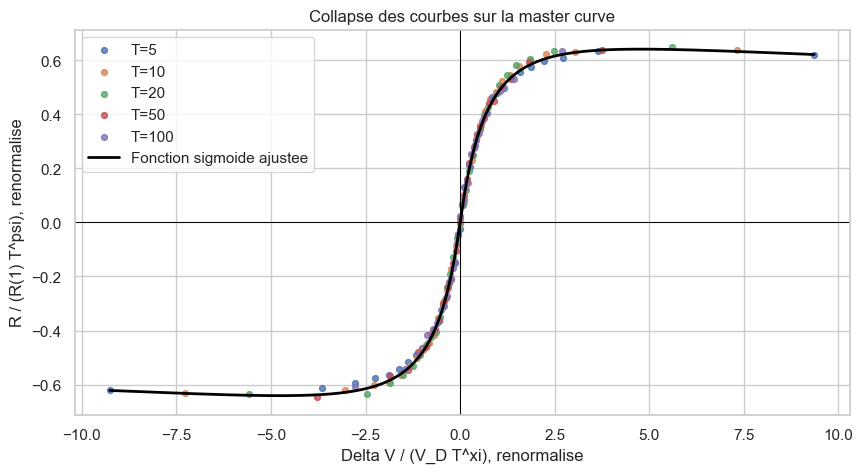

In [15]:
collapsed = renormalise_curve(impact_curve, fss_parameters)
x_master = np.linspace(collapsed["master_x"].min(), collapsed["master_x"].max(), 400)

fig, ax = plt.subplots(figsize=(10, 5))
for horizon, part in collapsed.groupby("horizon"):
    ax.scatter(part["master_x"], part["master_y"], s=18, alpha=0.8, label=f"T={horizon}")
ax.plot(
    x_master,
    master_curve(x_master, fss_parameters["alpha"], fss_parameters["beta"]),
    color="black",
    lw=2,
    label="Fonction sigmoide ajustee",
)
ax.axhline(0, color="black", lw=0.7)
ax.axvline(0, color="black", lw=0.7)
ax.set_xlabel("Delta V / (V_D T^xi), renormalise")
ax.set_ylabel("R / (R(1) T^psi), renormalise")
ax.set_title("Collapse des courbes sur la master curve")
ax.legend()
plt.show()

## 7. Liquidité et lambda de Kyle

Dans la zone linéaire autour de zéro:

$$
\frac{\partial R(\Delta V,T)}{\partial \Delta V}
=\frac{R_T}{V_T}.
$$

La pente est le lambda de Kyle. Avec les exposants de l'analyse
d'échelle finie:

$$
\lambda(T)\propto T^{-\lambda},
\qquad
\lambda=\xi-\psi.
$$

Une pente élevée signifie qu'un déséquilibre donné déplace davantage le
mid-price: le marché est alors moins liquide.

In [16]:
kyle_lambdas = estimate_kyle_lambdas(windows, central_quantile=0.35)
kyle_decay = fit_kyle_decay(kyle_lambdas)
display(kyle_lambdas)
display(pd.Series(kyle_decay, name="Ajustement direct").to_frame())
print(
    "Exposant predit par FSS xi - psi: "
    f"{fss_parameters['lambda_exponent']:.4f}"
)

,horizon,threshold_shares,intercept_cents,kyle_lambda_cents_per_share,observations
0,5,172.0,0.054901,0.024407,300345
1,10,291.0,0.105320,0.018626,149744
2,20,469.0,0.259172,0.015016,74777
3,50,893.0,0.622166,0.012373,29870
4,100,1470.0,0.799645,0.009858,14910


,Ajustement direct
prefactor,0.037488
lambda_exponent,0.290948


Exposant predit par FSS xi - psi: 0.3899


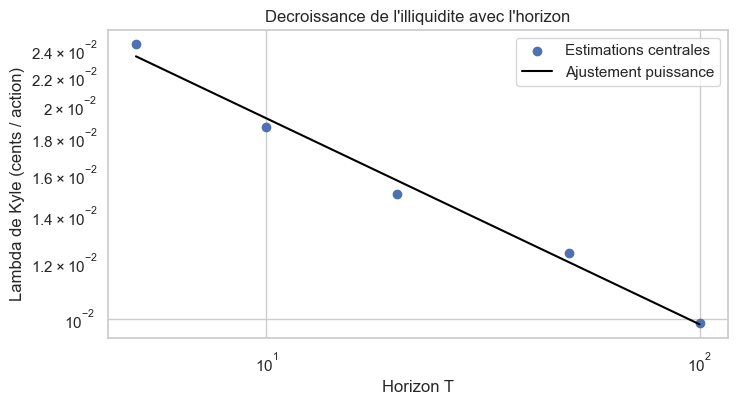

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
horizon_grid = np.linspace(min(HORIZONS), max(HORIZONS), 200)
ax.scatter(
    kyle_lambdas["horizon"],
    kyle_lambdas["kyle_lambda_cents_per_share"],
    label="Estimations centrales",
)
ax.plot(
    horizon_grid,
    kyle_decay["prefactor"] * horizon_grid ** (-kyle_decay["lambda_exponent"]),
    color="black",
    label="Ajustement puissance",
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Horizon T")
ax.set_ylabel("Lambda de Kyle (cents / action)")
ax.set_title("Decroissance de l'illiquidite avec l'horizon")
ax.legend()
plt.show()

## 8. Conclusion

Ce notebook relie les mécanismes microscopiques du carnet à une mesure
agrégée de liquidité:

- les événements visibles de type `4` consomment la liquidité affichée;
- leur signe initiateur permet de mesurer $R(\ell)$ et $R(v,1)$;
- leur volume signé agrégé forme $\Delta V$;
- les courbes $R(\Delta V,T)$ sont comparées entre horizons;
- la renormalisation produit une master curve sigmoïde;
- le lambda de Kyle mesure la pente centrale et donc l'illiquidité.

Les résultats numériques restent propres à TSLA en 2019 et au périmètre
volontairement restreint aux exécutions visibles.